In [3]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from sbi import analysis, utils
from sbi.inference import NPE, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
import seaborn as sns
import pandas as pd
import numpy as np
seed = 0
torch.manual_seed(seed);

In [4]:
from simulator import get_simulator, generate_dataset

In [5]:
# data
# Get simulator and generate dataset
task_params = {
    "results_path": "data/"
}
simulator_sir = get_simulator("sir", **task_params)
num_samples = 1000

In [6]:
prior = simulator_sir.prior_dist
prior, num_parameters, prior_returns_numpy = process_prior(prior)

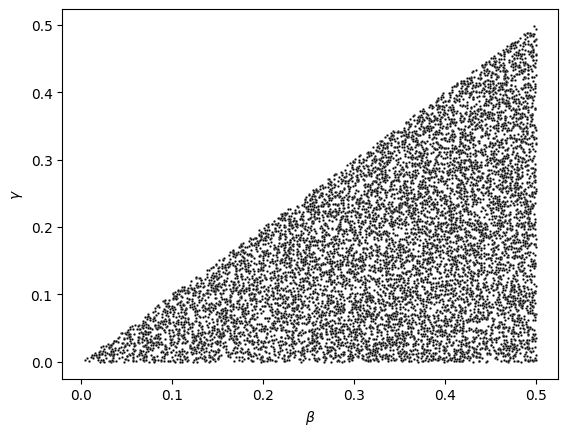

In [7]:
thetas = prior.sample((10000,))
thetas_df = pd.DataFrame({r"$\beta$": thetas[:,0], r"$\gamma$": thetas[:,1]})
_ = sns.scatterplot(thetas_df,x=r"$\beta$",y= r"$\gamma$",s=3, c='black')

In [8]:
import pickle
data_file = pickle.load(open('../data/seed=0_slab_scale=0.25_hyperprior=False_misspecified=True.pickle', 'rb'))
data = data_file["data"]
scales = data_file['scales']

/tmp/ipykernel_7031/1021867697.py:2: DeprecationWarning: Pickled array contains an aval with a named_shape attribute. This is deprecated and the code path supporting such avals will be removed. Please re-pickle the array.
  data_file = pickle.load(open('../data/seed=0_slab_scale=0.25_hyperprior=False_misspecified=True.pickle', 'rb'))


In [9]:
print("Data keys:", *data.keys(),"\nScales keys:" ,*scales.keys())

Data keys: theta theta_true x x_raw y y_raw 
Scales keys: theta_mean theta_std x_mean x_std


In [19]:
x=data['x_raw']
theta = data['theta']

<Axes: >

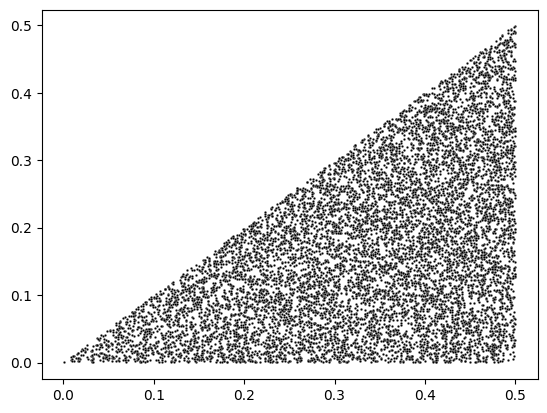

In [11]:
sns.scatterplot(x=theta[::5,0], y=theta[::5,1], s=3, c='black')

In [46]:
from sbi.neural_nets.embedding_nets import CNNEmbedding

embedding_net = CNNEmbedding(
    input_shape=(364,),
    in_channels=1,
    out_channels_per_layer=[6],
    num_conv_layers=1,
    num_linear_layers=1,
    output_dim=8,
    kernel_size=3,
    pool_kernel_size=5
)

In [47]:
from sbi.neural_nets import posterior_nn

# instantiate the neural density estimator
neural_posterior = posterior_nn(model="maf", embedding_net=embedding_net)

# setup the inference procedure with NPE
inferer = NPE(prior=prior, density_estimator=neural_posterior)

In [48]:
# run the inference procedure on one round and 10000 simulated data points
theta, x = data['theta'][:5000], data['x_raw'][:5000,1:]
theta = torch.from_numpy(np.array(theta)).to(torch.float32)
x = torch.from_numpy(np.array(x)).to(torch.float32)
# x = x.unsqueeze(1)
print(x.shape, theta.shape)

torch.Size([5000, 364]) torch.Size([5000, 2])


In [49]:
density_estimator = inferer.append_simulations(theta, x).train(training_batch_size=256)
posterior = inferer.build_posterior(density_estimator)

 Neural network successfully converged after 83 epochs.

In [50]:
true_parameter = theta[12].unsqueeze(0)
x_obs = x[12].unsqueeze(0)
samples = posterior.set_default_x(x_obs).sample((1000,))

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

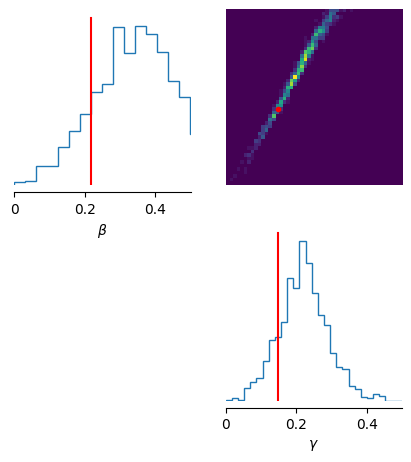

In [51]:
# create the figure
fig, ax = analysis.pairplot(
    samples,
    points=true_parameter,
    labels=[r"$\beta$", r"$\gamma$"],
    limits=[[0, 0.5], [0,0.5]],
    fig_kwargs=dict(
        points_colors="r",
        points_offdiag={"markersize": 6},
    ),
    figsize=(5, 5),
)

In [53]:
thetas = theta[:5000]
x_obs_g = x[:5000]
#lp = posterior.log_prob_batched(thetas.unsqueeze(0), x_obs_g)

In [40]:
prior.log_prob(thetas).mean()

IndexError: index 1 is out of bounds for dimension 1 with size 1

In [42]:
posterior.posterior_estimator.embedding_net(x_obs_g)

tensor([[0.2719, 0.0000, 0.3083,  ..., 0.2012, 0.0000, 0.0000],
        [1.1114, 0.0000, 0.0000,  ..., 0.0000, 2.4947, 0.0000],
        [0.5537, 0.0000, 0.0000,  ..., 0.0000, 2.7255, 0.0000],
        ...,
        [0.6875, 0.0000, 0.0000,  ..., 0.1612, 0.4845, 0.0000],
        [0.3961, 0.0000, 0.1192,  ..., 0.1317, 0.2179, 0.0000],
        [0.1731, 0.0000, 0.2982,  ..., 0.0000, 0.5822, 0.0000]],
       grad_fn=<ReluBackward0>)

In [56]:
t = posterior.posterior_estimator.sample((100,), x_obs_g).detach().cpu()
t.shape

torch.Size([100, 5000, 2])

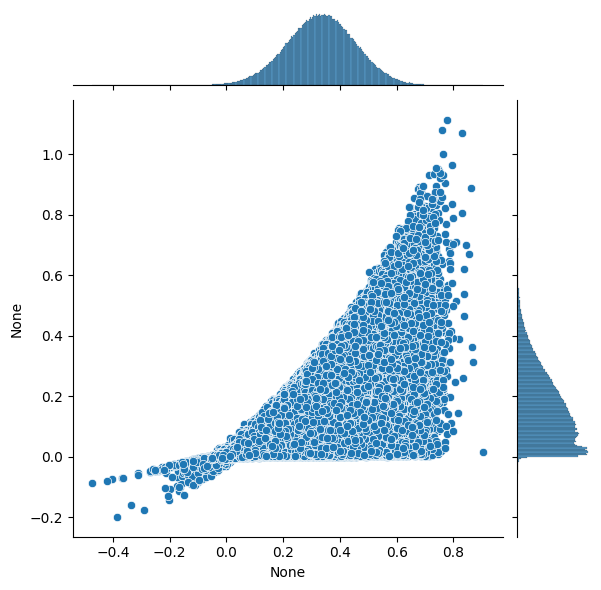

In [57]:
sns.jointplot(x=t[:,:,0].flatten(), y=t[:,:,1].flatten())

In [58]:
samples_g = posterior.sample_batched((1,), x_obs_g)

Drawing 1 posterior samples:   0%|          | 0/1 [00:00<?, ?it/s]

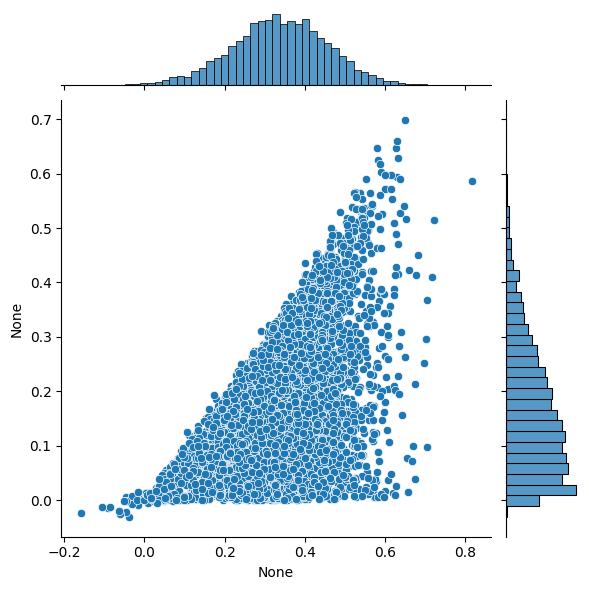

In [59]:
sns.jointplot(x=samples_g[0,:,0], y=samples_g[0,:,1])